# BQ1: Correlation Analysis - Portfolio Risk Attribution and Regime Detection

**Data Delta Force - Correlation Analysis**

> Quantify portfolio risk from crypto exposure under different U.S. macro regimes (rate hikes, inflation shocks, CPI changes, jobs data) and predict regime switches.

## Objectives
1. Calculate rolling correlations between crypto assets and macro indicators
2. Identify macro regime periods (rate hiking, inflation shock, economic expansion/contraction)
3. Analyze correlation dynamics across different regimes
4. Develop regime classification model
5. Generate portfolio risk metrics by regime

## Target Metrics
- Real-time risk decomposition with < 2% attribution error
- > 80% accuracy for regime classification
- VaR calculations with 99% confidence intervals
- 5-10 day lead time for correlation breakdown warnings

## 1. Setup and Data Loading

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from datetime import datetime, timedelta
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import glob
import os

warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.2)

# Configure pandas display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

print("Libraries imported successfully")
print(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Libraries imported successfully
Analysis Date: 2025-10-29 16:54


In [2]:
# Setup paths
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == 'notebooks':
    PROJECT_ROOT = NOTEBOOK_DIR.parent
    os.chdir(PROJECT_ROOT)
else:
    PROJECT_ROOT = NOTEBOOK_DIR

# Define data directories
DATA_DIR = Path('data')
CRYPTO_PRICES_DIR = DATA_DIR / 'raw' / 'crypto' / 'prices'
CRYPTO_MARKET_DIR = DATA_DIR / 'raw' / 'crypto' / 'market_data'
MACRO_DIR = DATA_DIR / 'raw' / 'macro'
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Directory: {DATA_DIR}")
print(f"Output Directory: {OUTPUT_DIR}")
print(f"\n Crypto Prices Dir Exists: {CRYPTO_PRICES_DIR.exists()}")
print(f"Macro Dir Exists: {MACRO_DIR.exists()}")

Project Root: c:\Users\rogej\Documents\data-delta-force
Data Directory: data
Output Directory: outputs

 Crypto Prices Dir Exists: True
Macro Dir Exists: True


In [ ]:
# Helper functions for data loading
def load_latest_file(directory, pattern='*.csv'):
    """Load the most recent CSV file from a directory."""
    files = list(Path(directory).glob(pattern))
    if not files:
        return None
    latest_file = max(files, key=lambda x: x.stat().st_mtime)
    print(f"   Loading: {latest_file.name}")
    return pd.read_csv(latest_file)

def load_crypto_price(crypto_name):
    """Load historical price data for a specific cryptocurrency.
    Handles both timestamp formats (milliseconds and datetime strings).
    """
    pattern = f'*{crypto_name}*.csv'
    df = load_latest_file(CRYPTO_PRICES_DIR, pattern)
    
    if df is not None:
        # Handle different timestamp column names and formats
        timestamp_col = None
        
        # Find the timestamp column
        if 'Timestamp' in df.columns:
            timestamp_col = 'Timestamp'
        elif 'timestamp' in df.columns:
            timestamp_col = 'timestamp'
        
        if timestamp_col:
            # Try parsing as milliseconds first
            try:
                df['date'] = pd.to_datetime(df[timestamp_col], unit='ms')
                print(f"      ✓ Parsed timestamps as milliseconds")
            except (ValueError, TypeError, pd.errors.OutOfBoundsDatetime):
                # If that fails, parse as string datetime
                try:
                    df['date'] = pd.to_datetime(df[timestamp_col])
                    print(f"      ✓ Parsed timestamps as datetime strings")
                except Exception as e:
                    print(f"      ⚠ Warning: Could not parse timestamps: {e}")
                    return None
        else:
            print(f"      ⚠ Warning: No timestamp column found")
            return None
        
        # Handle different price column names
        if 'Price' in df.columns and 'prices' not in df.columns:
            df['prices'] = df['Price']
        elif 'price' in df.columns and 'prices' not in df.columns:
            df['prices'] = df['price']
        
        if 'prices' not in df.columns:
            print(f"      ⚠ Warning: No price column found. Available columns: {list(df.columns)}")
            return None
        
        df = df.sort_values('date')
        return df
    
    return None

def load_macro_indicator(indicator_name):
    """Load macro indicator data from FRED."""
    # Try different subdirectories
    subdirs = ['employment', 'gdp', 'inflation', 'interest_rates']
    
    for subdir in subdirs:
        pattern = f'*{indicator_name}*.csv'
        target_dir = MACRO_DIR / subdir
        if target_dir.exists():
            df = load_latest_file(target_dir, pattern)
            if df is not None:
                if 'date' in df.columns:
                    df['date'] = pd.to_datetime(df['date'])
                    df = df.sort_values('date')
                return df
    return None

print("Helper functions defined")

✅ Helper functions defined


In [6]:
# Load cryptocurrency price data
print("Loading Cryptocurrency Data...")
crypto_list = ['bitcoin', 'ethereum', 'binancecoin', 'cardano', 'solana']
crypto_data = {}

for crypto in crypto_list:
    print(f"\n  {crypto.upper()}:")
    df = load_crypto_price(crypto)
    if df is not None:
        crypto_data[crypto] = df
        print(f"    Loaded {len(df)} records")
        print(f"    Date range: {df['date'].min()} to {df['date'].max()}")
    else:
        print(f"    No data found")

print(f"\n Loaded {len(crypto_data)} cryptocurrencies")

Loading Cryptocurrency Data...

  BITCOIN:
   Loading: coingecko_bitcoin_historical_20251022_144507.csv
      ✓ Parsed timestamps as datetime strings
    Loaded 366 records
    Date range: 2024-10-23 00:00:00 to 2025-10-22 14:44:23

  ETHEREUM:
   Loading: coingecko_ethereum_historical_20251022_144507.csv
      ✓ Parsed timestamps as datetime strings
    Loaded 366 records
    Date range: 2024-10-23 00:00:00 to 2025-10-22 14:44:45

  BINANCECOIN:
   Loading: coingecko_binancecoin_historical_20251022_144507.csv
      ✓ Parsed timestamps as datetime strings
    Loaded 366 records
    Date range: 2024-10-23 00:00:00 to 2025-10-22 14:44:54

  CARDANO:
   Loading: coingecko_cardano_historical_20251022_144508.csv
      ✓ Parsed timestamps as datetime strings
    Loaded 366 records
    Date range: 2024-10-23 00:00:00 to 2025-10-22 14:44:42

  SOLANA:
   Loading: coingecko_solana_historical_20251022_144509.csv
      ✓ Parsed timestamps as datetime strings
    Loaded 366 records
    Date range:

In [8]:
# Load macroeconomic indicators
print("\n Loading Macroeconomic Indicators...")
macro_indicators = {
    'fed_funds_rate': 'fed',
    'cpi': 'cpi',
    'unemployment': 'unemployment',
    'gdp': 'gdp',
    '10y_treasury': '10y',
    '2y_treasury': '2y'
}

macro_data = {}
for key, search_term in macro_indicators.items():
    print(f"\n  {key.upper()}:")
    df = load_macro_indicator(search_term)
    if df is not None:
        macro_data[key] = df
        print(f"    Loaded {len(df)} records")
        if 'date' in df.columns:
            print(f"    Date range: {df['date'].min()} to {df['date'].max()}")
    else:
        print(f"    No data found")

print(f"\n Loaded {len(macro_data)} macro indicators")


 Loading Macroeconomic Indicators...

  FED_FUNDS_RATE:
   Loading: fred_fed_funds_rate_interest_rates_20251022_144542.csv
    Loaded 29 records
    Date range: 2025-09-22 00:00:00 to 2025-10-20 00:00:00

  CPI:
   Loading: fred_cpi_inflation_20251022_144511.csv
    Loaded 68 records
    Date range: 2020-01-01 00:00:00 to 2025-08-01 00:00:00

  UNEMPLOYMENT:
   Loading: fred_unemployment_rate_employment_20251022_144511.csv
    Loaded 68 records
    Date range: 2020-01-01 00:00:00 to 2025-08-01 00:00:00

  GDP:
   Loading: fred_gdp_gdp_20251022_144511.csv
    Loaded 22 records
    Date range: 2020-01-01 00:00:00 to 2025-04-01 00:00:00

  10Y_TREASURY:
   Loading: fred_10y_treasury_interest_rates_20251022_144543.csv
    Loaded 21 records
    Date range: 2025-09-22 00:00:00 to 2025-10-20 00:00:00

  2Y_TREASURY:
   Loading: fred_2y_treasury_interest_rates_20251022_144543.csv
    Loaded 21 records
    Date range: 2025-09-22 00:00:00 to 2025-10-20 00:00:00

 Loaded 6 macro indicators


## 2. Data Preprocessing and Alignment

In [9]:
# Create unified dataset with daily frequency
print("Creating unified daily dataset...\n")

# Start with Bitcoin as the base (daily prices)
if 'bitcoin' in crypto_data:
    base_df = crypto_data['bitcoin'][['date', 'prices']].copy()
    base_df = base_df.rename(columns={'prices': 'btc_price'})
    base_df = base_df.set_index('date')
    
    # Add other crypto prices
    for crypto in crypto_list[1:]:
        if crypto in crypto_data:
            df = crypto_data[crypto][['date', 'prices']].copy()
            df = df.rename(columns={'prices': f'{crypto[:3]}_price'})
            df = df.set_index('date')
            base_df = base_df.join(df, how='outer')
    
    # Forward fill crypto prices (for weekends/holidays)
    base_df = base_df.ffill()
    
    # Add macro indicators (forward fill for daily frequency)
    for key, df in macro_data.items():
        if 'date' in df.columns and 'value' in df.columns:
            macro_df = df[['date', 'value']].copy()
            macro_df = macro_df.rename(columns={'value': key})
            macro_df = macro_df.set_index('date')
            base_df = base_df.join(macro_df, how='outer')
    
    # Forward fill macro data
    base_df = base_df.ffill()
    
    # Drop rows with any NaN values
    unified_df = base_df.dropna()
    
    print(f"Unified dataset created")
    print(f"   Shape: {unified_df.shape}")
    print(f"   Date range: {unified_df.index.min()} to {unified_df.index.max()}")
    print(f"   Columns: {list(unified_df.columns)}")
    
    display(unified_df.head())
    display(unified_df.describe())
else:
    print("Bitcoin data not available")
    unified_df = None

Creating unified daily dataset...

Unified dataset created
   Shape: (36, 11)
   Date range: 2025-09-22 00:00:00 to 2025-10-22 14:44:54
   Columns: ['btc_price', 'eth_price', 'bin_price', 'car_price', 'sol_price', 'fed_funds_rate', 'cpi', 'unemployment', 'gdp', '10y_treasury', '2y_treasury']


,btc_price,eth_price,bin_price,car_price,sol_price,fed_funds_rate,cpi,unemployment,gdp,10y_treasury,2y_treasury
date,,,,,,,,,,,
2025-09-22,"115,304.4800","4,452.8711","1,048.5650",0.8850,236.6487,4.0900,323.3640,4.3000,"30,485.7290",4.1500,3.6100
2025-09-23,"112,696.7410","4,199.9518",992.3882,0.8256,220.3369,4.0900,323.3640,4.3000,"30,485.7290",4.1200,3.5300
2025-09-24,"112,022.1659","4,166.1905","1,017.4645",0.8089,214.1793,4.0900,323.3640,4.3000,"30,485.7290",4.1600,3.5700
2025-09-25,"113,320.5691","4,148.6568","1,018.0678",0.8124,211.5961,4.0900,323.3640,4.3000,"30,485.7290",4.1800,3.6400
2025-09-26,"108,963.5301","3,863.0633",944.4004,0.7619,192.1817,4.0900,323.3640,4.3000,"30,485.7290",4.2000,3.6300


,btc_price,eth_price,bin_price,car_price,sol_price,fed_funds_rate,cpi,unemployment,gdp,10y_treasury,2y_treasury
count,36.0000,36.0000,36.0000,36.0000,36.0000,36.0000,36.0000,36.0000,36.0000,36.0000,36.0000
mean,"113,551.4419","4,124.7164","1,105.4630",0.7444,204.8773,4.0989,323.3640,4.3000,"30,485.7290",4.0847,3.5331
std,"5,608.7694",265.6219,102.4234,0.0930,18.4019,0.0089,0.0000,0.0000,0.0000,0.0723,0.0674
min,"106,443.6119","3,749.2182",944.4004,0.6252,178.3062,4.0900,323.3640,4.3000,"30,485.7290",3.9900,3.4100
25%,"108,587.3768","3,877.4872","1,028.9779",0.6426,187.1165,4.0900,323.3640,4.3000,"30,485.7290",4.0150,3.4600
50%,"112,419.6573","4,135.3641","1,081.2888",0.7715,204.3474,4.1000,323.3640,4.3000,"30,485.7290",4.0750,3.5250
75%,"116,104.1711","4,350.1263","1,162.6706",0.8222,220.8357,4.1100,323.3640,4.3000,"30,485.7290",4.1425,3.5850
max,"124,773.5082","4,689.1317","1,311.7129",0.8850,236.6487,4.1100,323.3640,4.3000,"30,485.7290",4.2000,3.6400


In [10]:
# Calculate returns for crypto assets
if unified_df is not None:
    print("Calculating daily returns...\n")
    
    returns_df = unified_df.copy()
    
    # Calculate log returns for crypto prices
    price_cols = [col for col in unified_df.columns if '_price' in col]
    for col in price_cols:
        return_col = col.replace('_price', '_return')
        returns_df[return_col] = np.log(unified_df[col] / unified_df[col].shift(1))
    
    # Calculate percentage changes for macro indicators
    macro_cols = [col for col in unified_df.columns if '_price' not in col]
    for col in macro_cols:
        change_col = f"{col}_change"
        returns_df[change_col] = unified_df[col].pct_change()
    
    # Remove first row with NaN returns
    returns_df = returns_df.dropna()
    
    print(f"Returns calculated")
    print(f"   Shape: {returns_df.shape}")
    print(f"   Date range: {returns_df.index.min()} to {returns_df.index.max()}")
    
    # Display return statistics
    return_cols = [col for col in returns_df.columns if '_return' in col]
    print(f"\n Return Statistics (annualized):")
    for col in return_cols:
        mean_return = returns_df[col].mean() * 252  # Annualized
        volatility = returns_df[col].std() * np.sqrt(252)  # Annualized
        sharpe = mean_return / volatility if volatility != 0 else 0
        print(f"   {col:20s}: Mean={mean_return:7.2%}, Vol={volatility:7.2%}, Sharpe={sharpe:6.2f}")
else:
    returns_df = None

Calculating daily returns...

Returns calculated
   Shape: (35, 22)
   Date range: 2025-09-23 00:00:00 to 2025-10-22 14:44:54

 Return Statistics (annualized):
   btc_return          : Mean=-47.94%, Vol= 34.47%, Sharpe= -1.39
   eth_return          : Mean=-113.80%, Vol= 63.10%, Sharpe= -1.80
   bin_return          : Mean= 16.09%, Vol= 76.93%, Sharpe=  0.21
   car_return          : Mean=-242.16%, Vol= 86.13%, Sharpe= -2.81
   sol_return          : Mean=-184.97%, Vol= 76.52%, Sharpe= -2.42


## 3. Static Correlation Analysis

Calculating static correlations...



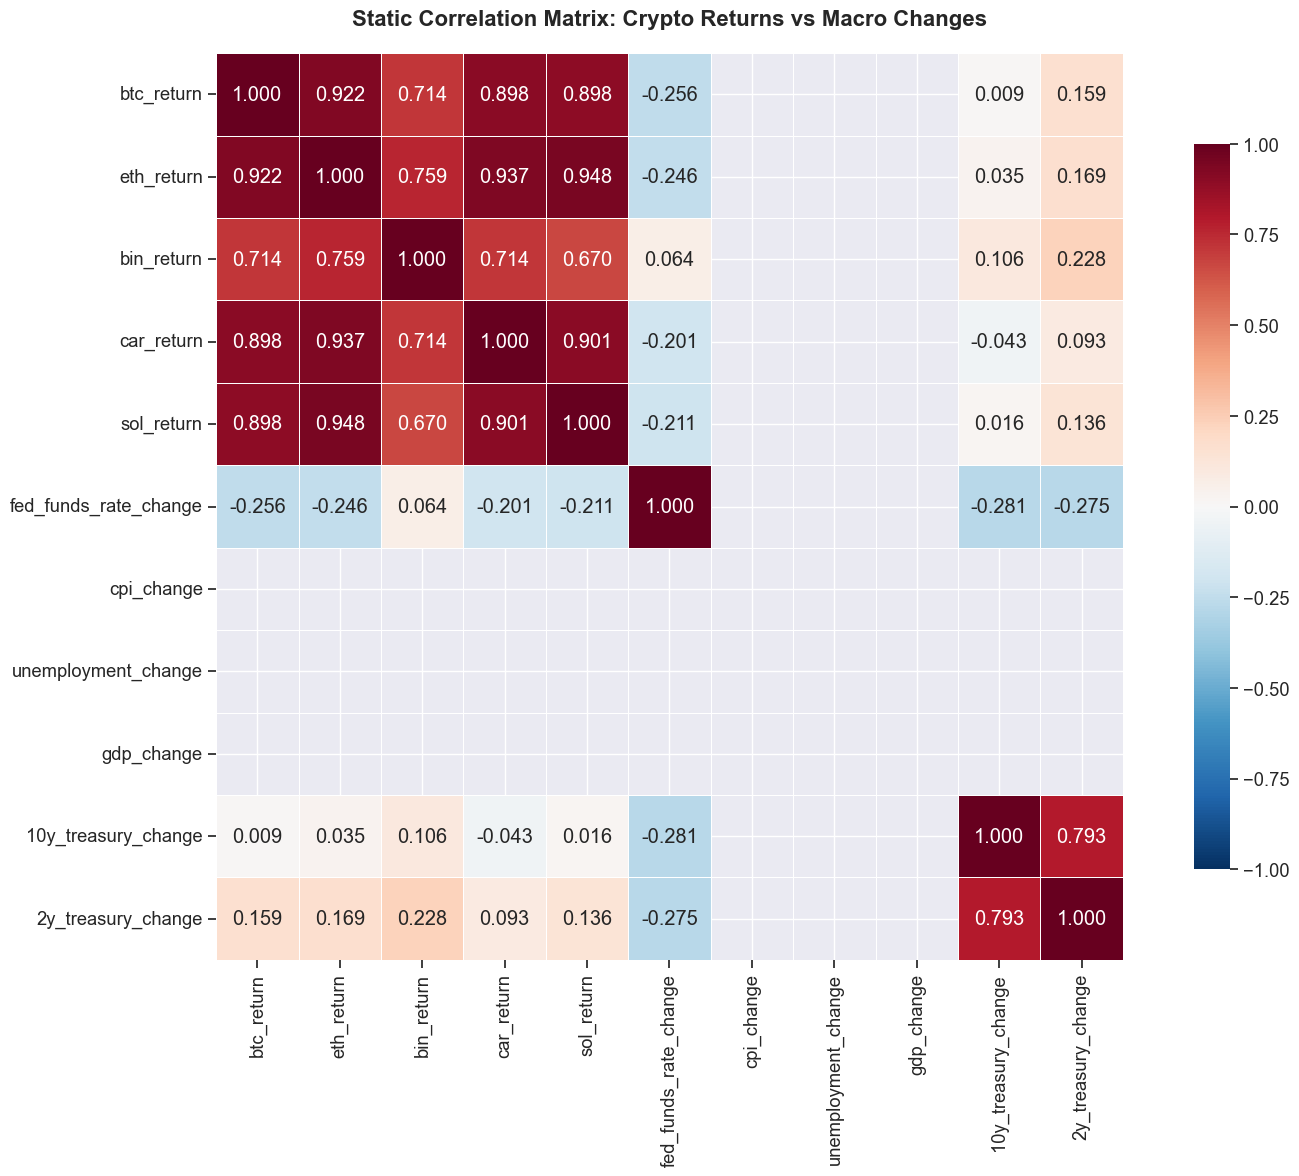


 Correlation matrix saved to outputs/correlation_matrix_full.png


In [11]:
# Calculate static correlation matrix
if returns_df is not None:
    print("Calculating static correlations...\n")
    
    # Select relevant columns for correlation
    crypto_return_cols = [col for col in returns_df.columns if '_return' in col]
    macro_change_cols = [col for col in returns_df.columns if '_change' in col]
    
    correlation_cols = crypto_return_cols + macro_change_cols
    corr_df = returns_df[correlation_cols].copy()
    
    # Calculate correlation matrix
    correlation_matrix = corr_df.corr()
    
    # Visualize full correlation matrix
    plt.figure(figsize=(16, 12))
    sns.heatmap(correlation_matrix, 
                annot=True, 
                fmt='.3f', 
                cmap='RdBu_r', 
                center=0, 
                vmin=-1, 
                vmax=1,
                square=True,
                linewidths=0.5,
                cbar_kws={"shrink": 0.8})
    plt.title('Static Correlation Matrix: Crypto Returns vs Macro Changes', 
              fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'correlation_matrix_full.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n Correlation matrix saved to outputs/correlation_matrix_full.png")

Analyzing Crypto-Macro Correlations...



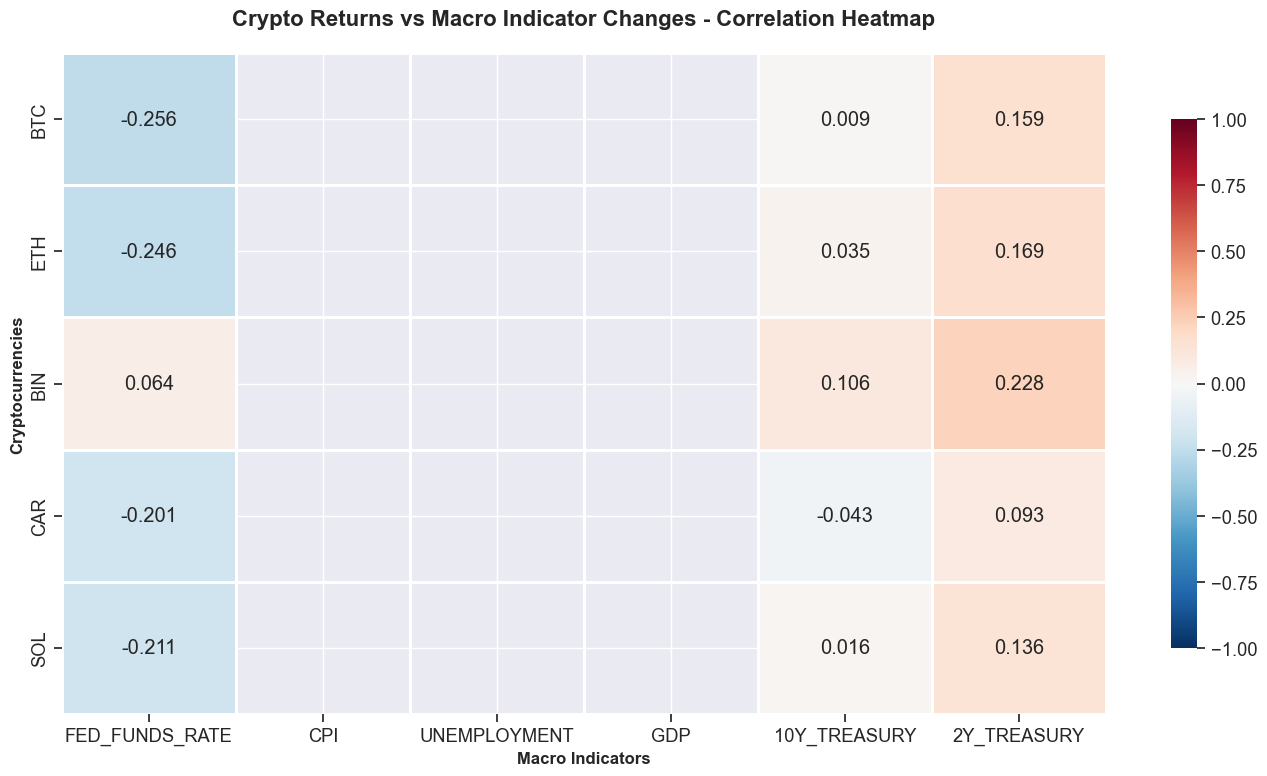


 Crypto-Macro Correlation Matrix:


,FED_FUNDS_RATE,CPI,UNEMPLOYMENT,GDP,10Y_TREASURY,2Y_TREASURY
BTC,-0.256,nan,nan,nan,0.009,0.159
ETH,-0.246,nan,nan,nan,0.035,0.169
BIN,0.064,nan,nan,nan,0.106,0.228
CAR,-0.201,nan,nan,nan,-0.043,0.093
SOL,-0.211,nan,nan,nan,0.016,0.136



 Strongest Correlations (|r| > 0.3):

 Crypto-macro correlation analysis saved


In [12]:
# Focus on crypto-macro correlations
if returns_df is not None:
    print("Analyzing Crypto-Macro Correlations...\n")
    
    # Extract crypto-macro correlation subset
    crypto_macro_corr = correlation_matrix.loc[crypto_return_cols, macro_change_cols]
    
    # Clean up column names for display
    crypto_macro_corr.index = [col.replace('_return', '').upper() for col in crypto_macro_corr.index]
    crypto_macro_corr.columns = [col.replace('_change', '').upper() for col in crypto_macro_corr.columns]
    
    # Visualize crypto-macro correlations
    plt.figure(figsize=(14, 8))
    sns.heatmap(crypto_macro_corr, 
                annot=True, 
                fmt='.3f', 
                cmap='RdBu_r', 
                center=0, 
                vmin=-1, 
                vmax=1,
                linewidths=1,
                cbar_kws={"shrink": 0.8})
    plt.title('Crypto Returns vs Macro Indicator Changes - Correlation Heatmap', 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Macro Indicators', fontsize=12, fontweight='bold')
    plt.ylabel('Cryptocurrencies', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'correlation_crypto_macro.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Display correlation table
    print("\n Crypto-Macro Correlation Matrix:")
    display(crypto_macro_corr.style.background_gradient(cmap='RdBu_r', vmin=-1, vmax=1)
                                    .format('{:.3f}'))
    
    # Identify strongest correlations
    print("\n Strongest Correlations (|r| > 0.3):")
    for crypto in crypto_macro_corr.index:
        for macro in crypto_macro_corr.columns:
            corr_val = crypto_macro_corr.loc[crypto, macro]
            if abs(corr_val) > 0.3:
                direction = "positive" if corr_val > 0 else "negative"
                print(f"   {crypto} ↔ {macro}: {corr_val:+.3f} ({direction})")
    
    print("\n Crypto-macro correlation analysis saved")

## 4. Rolling Correlation Analysis

In [13]:
# Calculate rolling correlations
if returns_df is not None:
    print("Calculating rolling correlations...\n")
    
    # Define rolling windows (in days)
    windows = [30, 60, 90, 180]
    
    # Focus on Bitcoin vs key macro indicators
    btc_return = 'btc_return'
    key_macros = ['fed_funds_rate_change', 'cpi_change', 'unemployment_change']
    
    # Check which columns exist
    available_macros = [col for col in key_macros if col in returns_df.columns]
    
    if btc_return in returns_df.columns and available_macros:
        rolling_correlations = {}
        
        for window in windows:
            print(f"  Calculating {window}-day rolling correlations...")
            rolling_correlations[window] = {}
            
            for macro in available_macros:
                # Calculate rolling correlation
                rolling_corr = returns_df[btc_return].rolling(window=window).corr(returns_df[macro])
                rolling_correlations[window][macro] = rolling_corr
        
        print("\n Rolling correlations calculated")
    else:
        print(" Required columns not found for rolling correlation")
        rolling_correlations = None
else:
    rolling_correlations = None

Calculating rolling correlations...

  Calculating 30-day rolling correlations...
  Calculating 60-day rolling correlations...
  Calculating 90-day rolling correlations...
  Calculating 180-day rolling correlations...

 Rolling correlations calculated


📊 Visualizing rolling correlations...



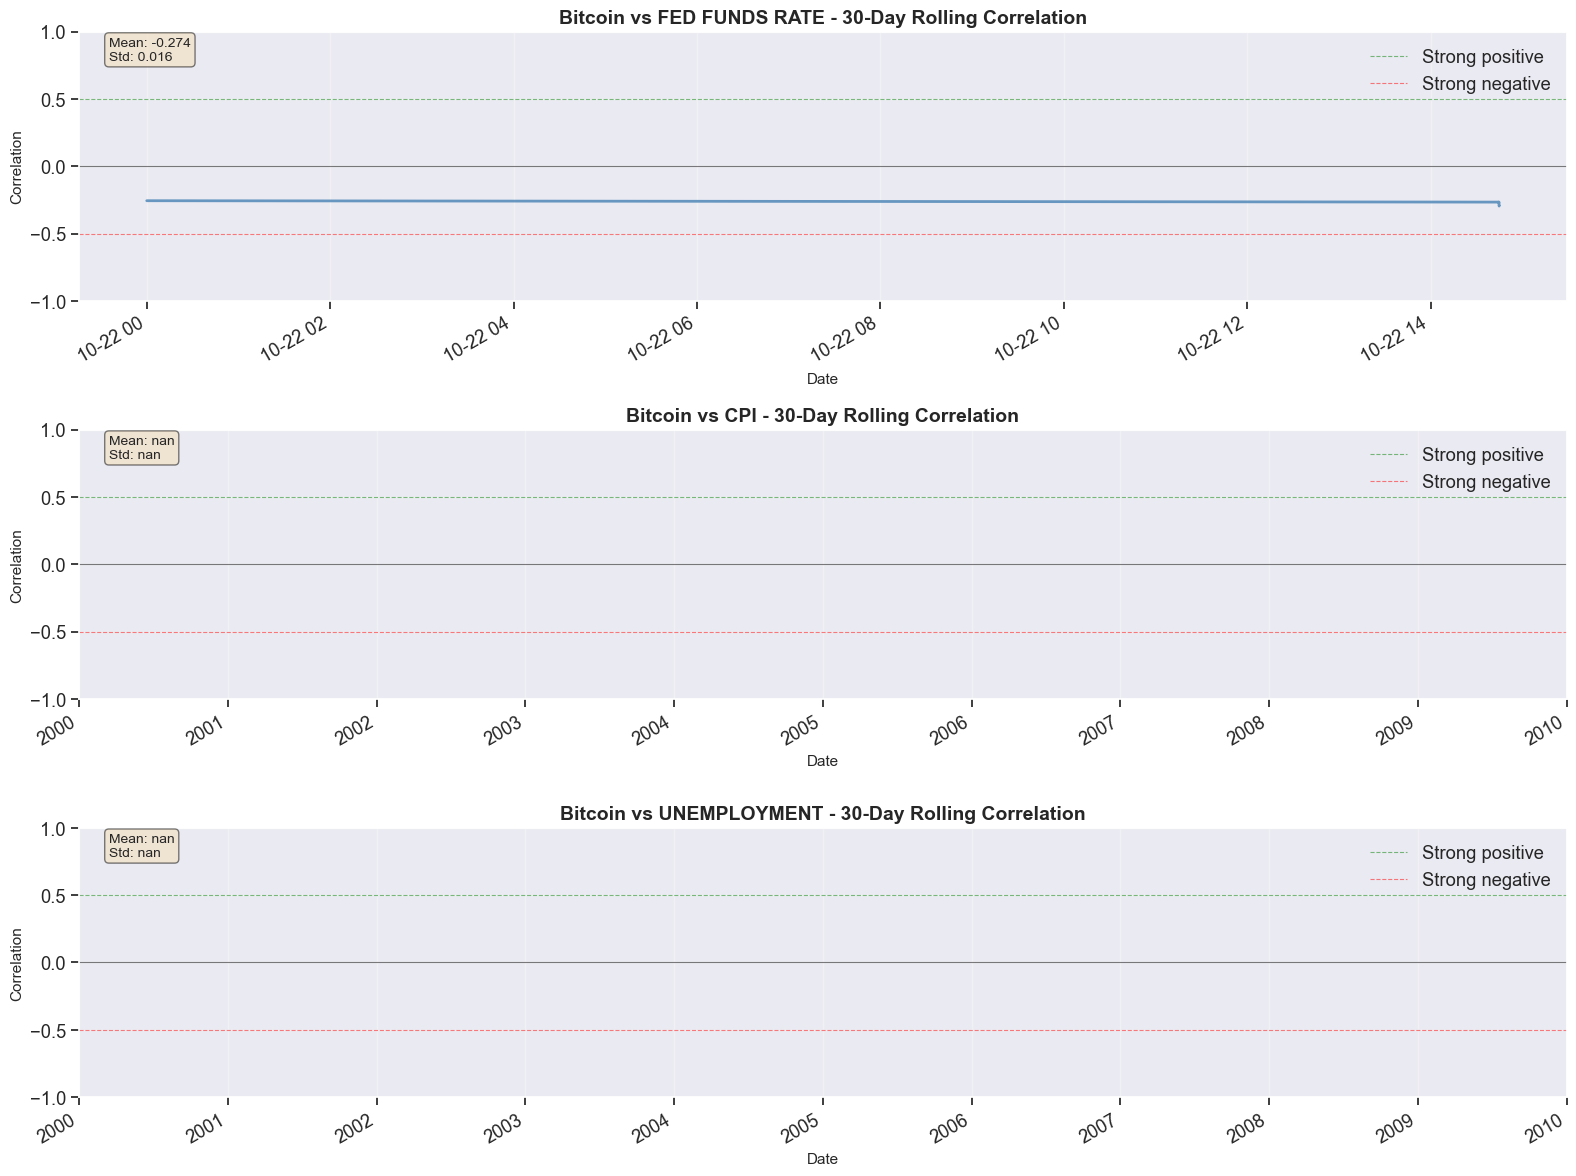

✅ 30-day rolling correlation plot saved


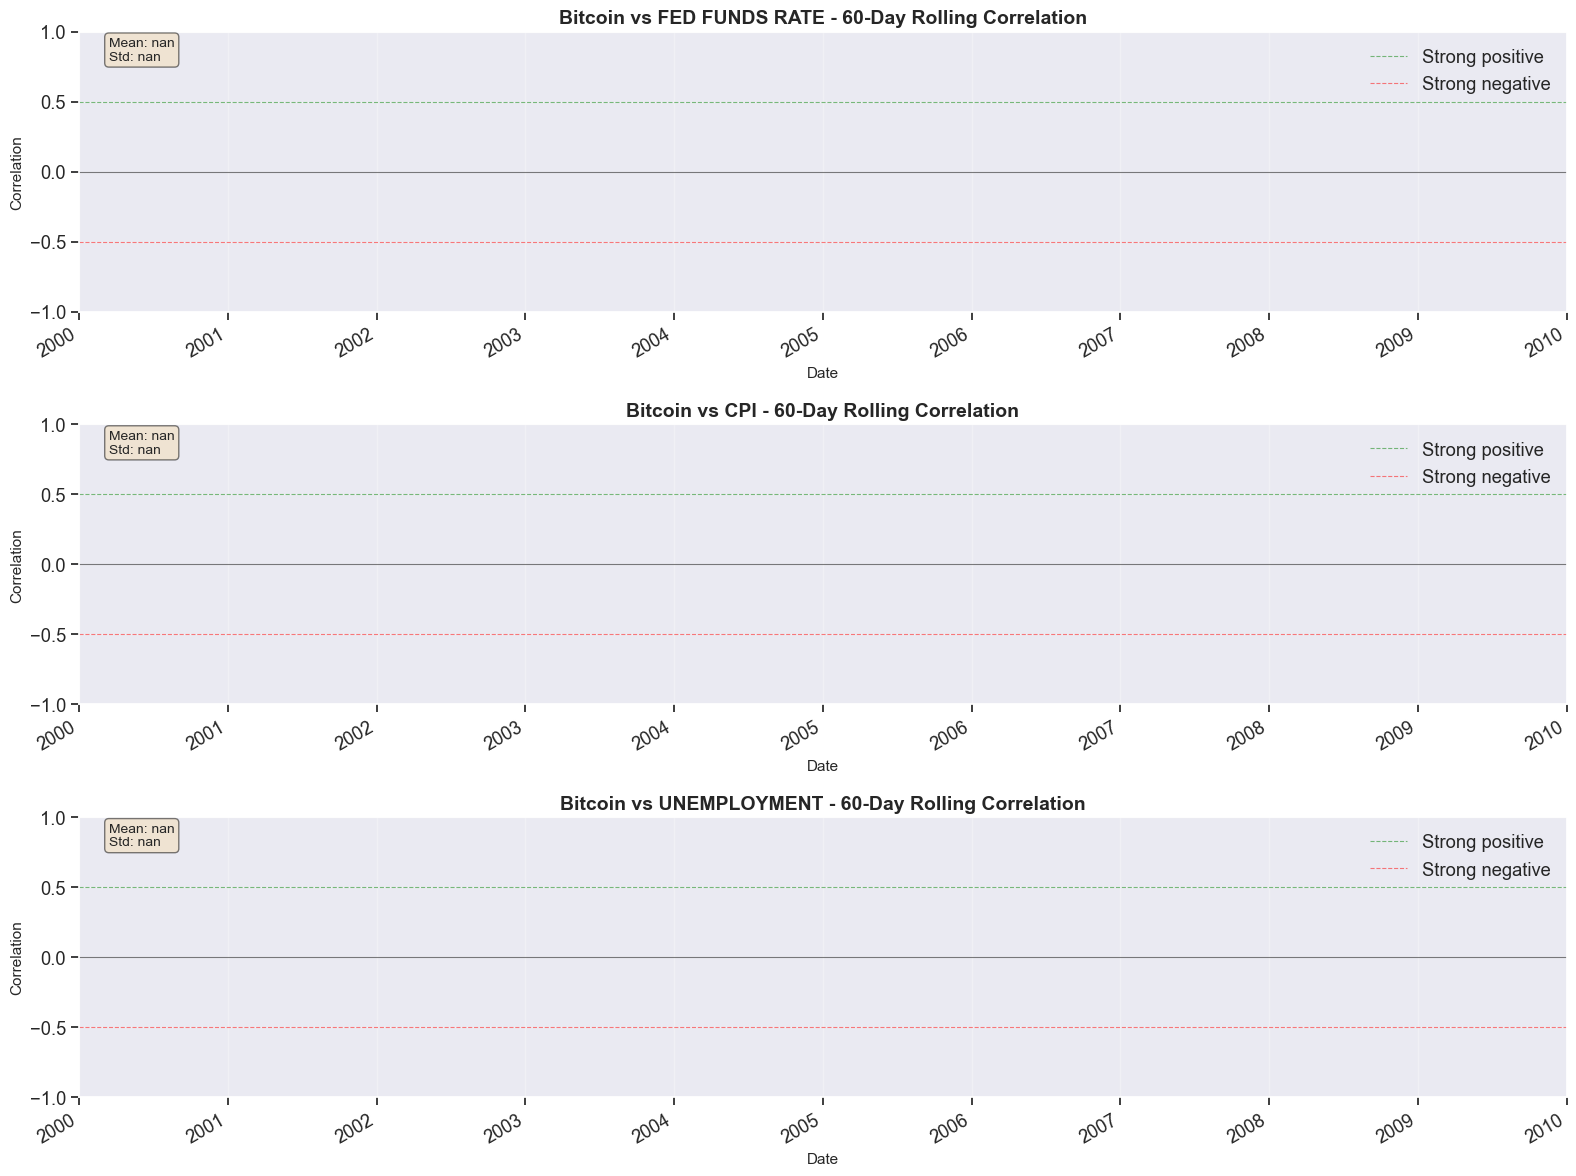

✅ 60-day rolling correlation plot saved


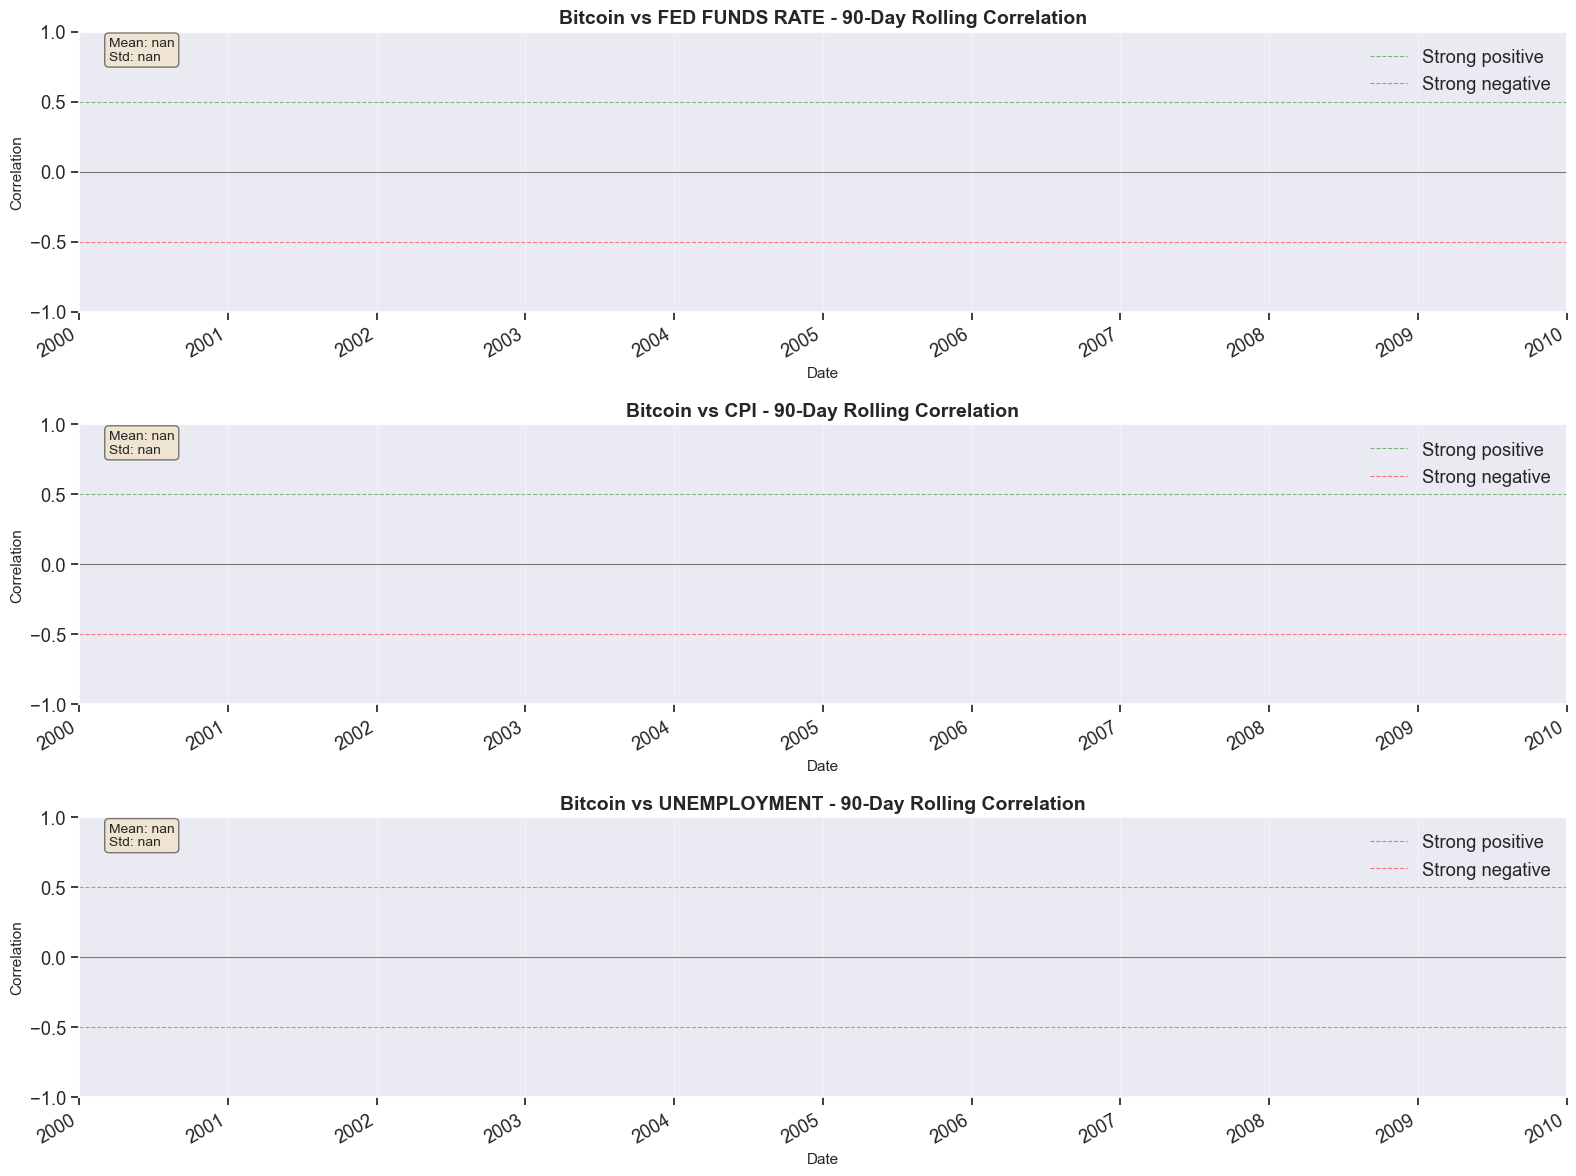

✅ 90-day rolling correlation plot saved


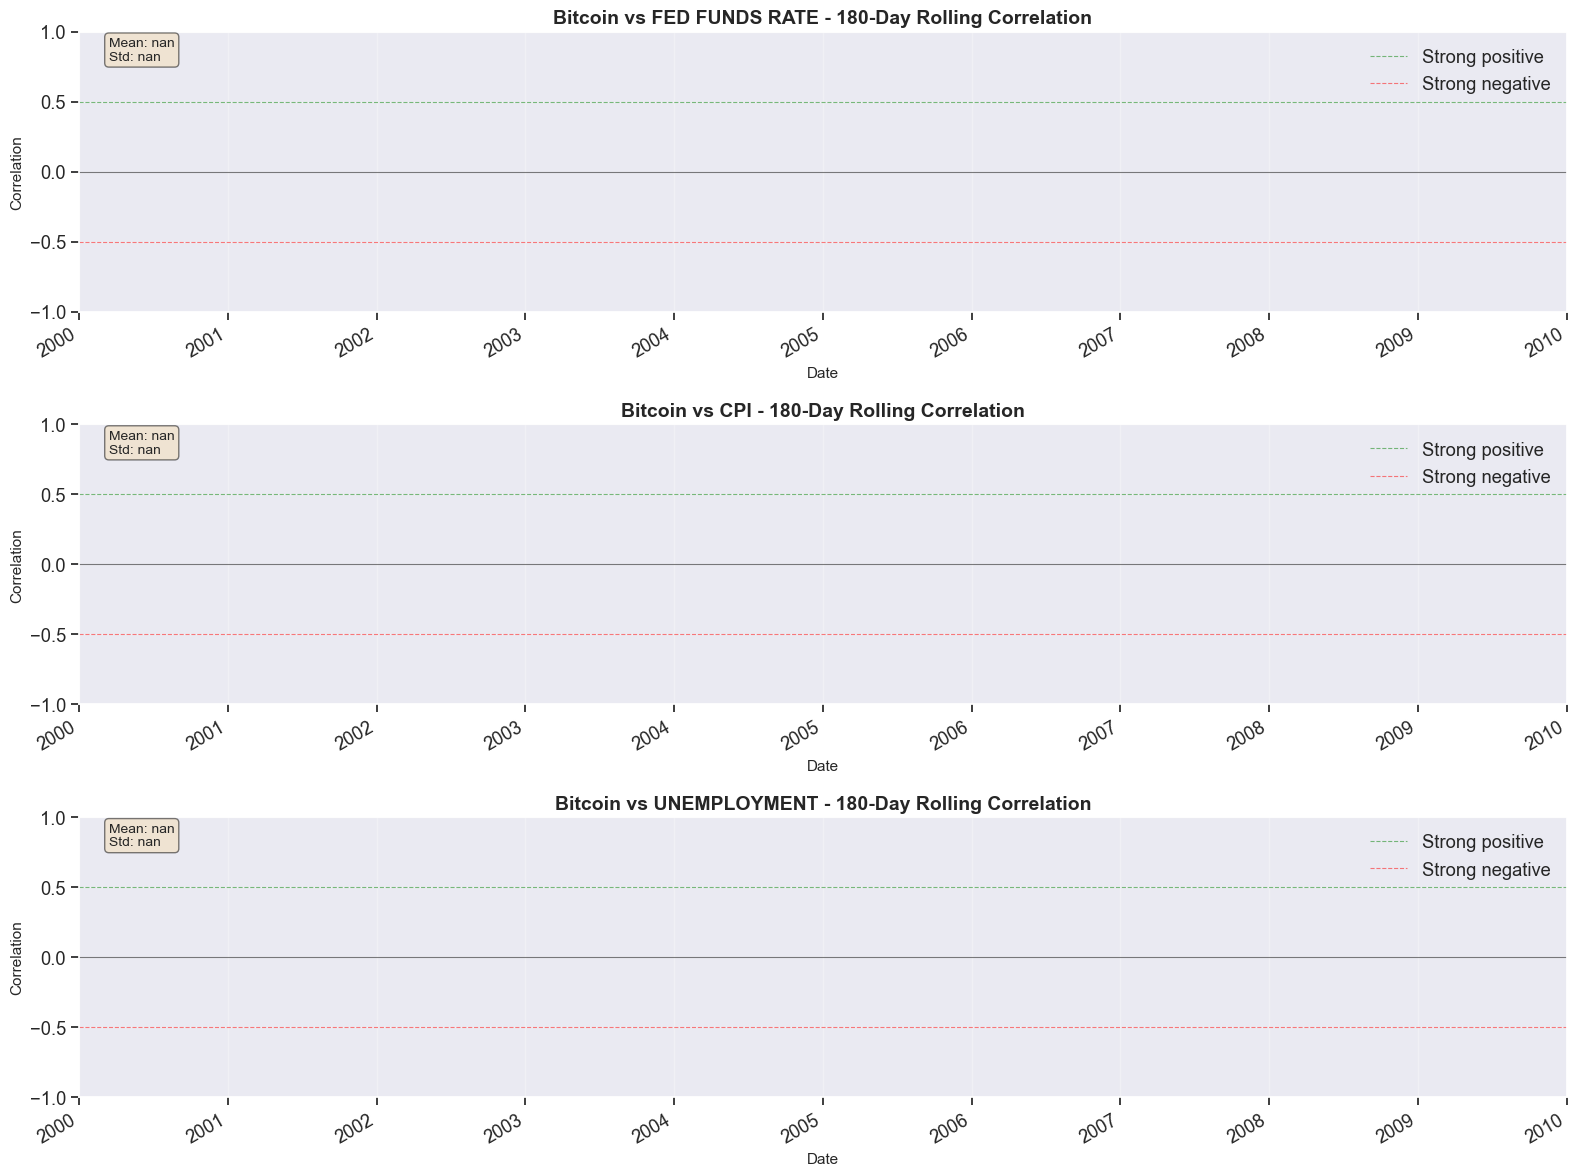

✅ 180-day rolling correlation plot saved

✅ All rolling correlation plots generated


In [14]:
# Visualize rolling correlations
if rolling_correlations:
    print("📊 Visualizing rolling correlations...\n")
    
    for window in windows:
        n_macros = len(rolling_correlations[window])
        fig, axes = plt.subplots(n_macros, 1, figsize=(16, 4*n_macros))
        
        if n_macros == 1:
            axes = [axes]
        
        for ax, (macro, corr_series) in zip(axes, rolling_correlations[window].items()):
            # Plot rolling correlation
            corr_series.plot(ax=ax, linewidth=2, color='steelblue', alpha=0.8)
            
            # Add horizontal reference lines
            ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
            ax.axhline(y=0.5, color='green', linestyle='--', linewidth=0.8, alpha=0.5, label='Strong positive')
            ax.axhline(y=-0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='Strong negative')
            
            # Formatting
            macro_label = macro.replace('_change', '').replace('_', ' ').upper()
            ax.set_title(f'Bitcoin vs {macro_label} - {window}-Day Rolling Correlation', 
                        fontsize=14, fontweight='bold')
            ax.set_xlabel('Date', fontsize=11)
            ax.set_ylabel('Correlation', fontsize=11)
            ax.set_ylim(-1, 1)
            ax.grid(alpha=0.3)
            ax.legend(loc='best')
            
            # Add correlation statistics
            mean_corr = corr_series.mean()
            std_corr = corr_series.std()
            textstr = f'Mean: {mean_corr:.3f}\nStd: {std_corr:.3f}'
            ax.text(0.02, 0.98, textstr, transform=ax.transAxes, 
                   fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f'rolling_correlation_{window}day.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"✅ {window}-day rolling correlation plot saved")
    
    print("\n✅ All rolling correlation plots generated")

## 5. Macro Regime Detection

In [15]:
# Define macro regimes based on economic indicators
if unified_df is not None:
    print("📊 Detecting macro regimes...\n")
    
    regime_df = unified_df.copy()
    
    # Calculate moving averages for trend detection
    if 'fed_funds_rate' in regime_df.columns:
        regime_df['fed_rate_ma30'] = regime_df['fed_funds_rate'].rolling(30).mean()
        regime_df['fed_rate_trend'] = (regime_df['fed_funds_rate'] > regime_df['fed_rate_ma30']).astype(int)
    
    if 'cpi' in regime_df.columns:
        regime_df['cpi_yoy'] = regime_df['cpi'].pct_change(252)  # Year-over-year
        regime_df['high_inflation'] = (regime_df['cpi_yoy'] > 0.03).astype(int)  # >3% threshold
    
    if 'unemployment' in regime_df.columns:
        regime_df['unemployment_ma90'] = regime_df['unemployment'].rolling(90).mean()
        regime_df['rising_unemployment'] = (regime_df['unemployment'] > regime_df['unemployment_ma90']).astype(int)
    
    # Define composite regime
    # Regime 0: Low inflation, stable/falling rates, low unemployment (Risk-On)
    # Regime 1: Rising rates (Tightening)
    # Regime 2: High inflation (Inflation Shock)
    # Regime 3: Rising unemployment (Economic Stress)
    
    regime_conditions = []
    
    if 'fed_rate_trend' in regime_df.columns:
        regime_conditions.append(regime_df['fed_rate_trend'])
    
    if 'high_inflation' in regime_df.columns:
        regime_conditions.append(regime_df['high_inflation'] * 2)
    
    if 'rising_unemployment' in regime_df.columns:
        regime_conditions.append(regime_df['rising_unemployment'] * 3)
    
    if regime_conditions:
        regime_df['regime_score'] = sum(regime_conditions)
        
        # Map scores to regime labels
        def label_regime(score):
            if score == 0:
                return 'Risk-On'
            elif score == 1:
                return 'Tightening'
            elif score >= 2 and score < 4:
                return 'Inflation Shock'
            else:
                return 'Economic Stress'
        
        regime_df['regime'] = regime_df['regime_score'].apply(label_regime)
        
        # Drop rows with NaN regime
        regime_df = regime_df.dropna(subset=['regime'])
        
        print("✅ Regimes detected")
        print(f"\n📊 Regime Distribution:")
        print(regime_df['regime'].value_counts())
        print(f"\n📊 Regime Periods:")
        print(regime_df.groupby('regime').agg(
            start_date=('regime', 'first'),
            end_date=('regime', 'last'),
            days=('regime', 'count')
        ))
    else:
        print("❌ Insufficient data for regime detection")
        regime_df = None
else:
    regime_df = None

📊 Detecting macro regimes...

✅ Regimes detected

📊 Regime Distribution:
regime
Risk-On       29
Tightening     7
Name: count, dtype: int64

📊 Regime Periods:
            start_date    end_date  days
regime                                  
Risk-On        Risk-On     Risk-On    29
Tightening  Tightening  Tightening     7


📊 Visualizing macro regimes...



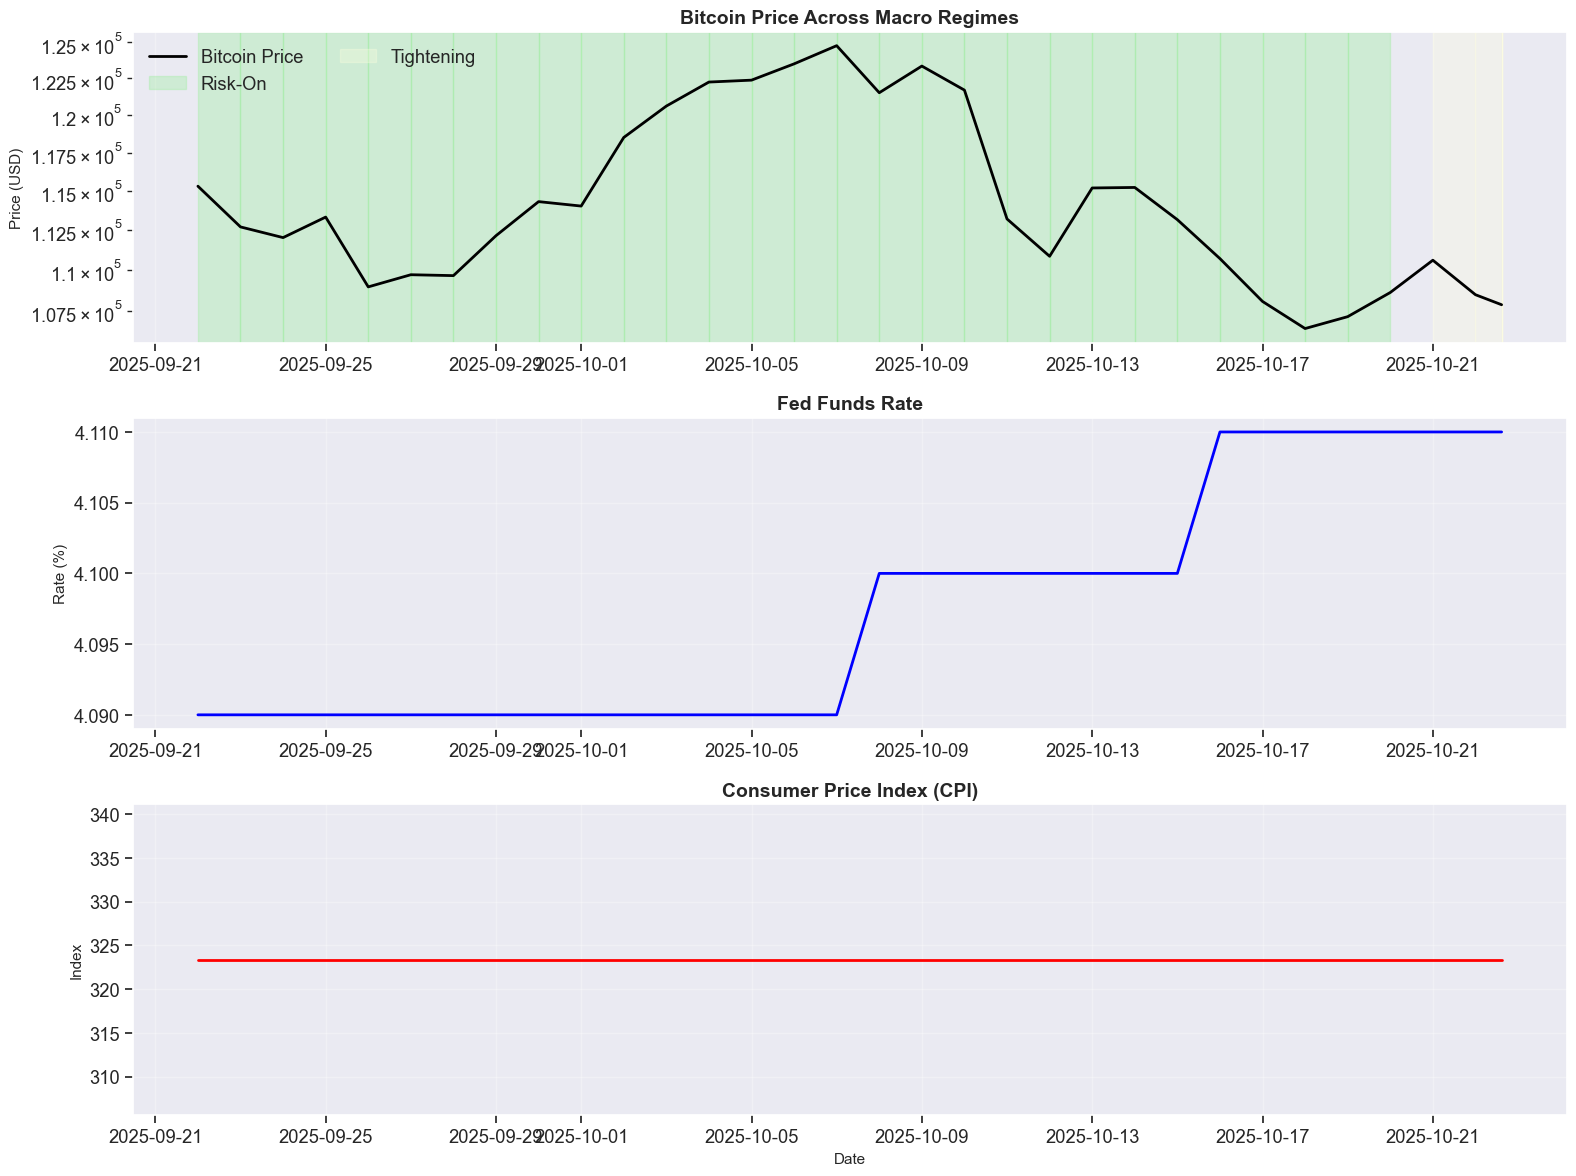

✅ Regime timeline visualization saved


In [16]:
# Visualize regimes over time
if regime_df is not None and 'regime' in regime_df.columns:
    print("📊 Visualizing macro regimes...\n")
    
    # Create regime timeline
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    
    # Plot 1: Bitcoin price with regime background
    if 'btc_price' in regime_df.columns:
        ax1 = axes[0]
        
        # Plot Bitcoin price
        ax1.plot(regime_df.index, regime_df['btc_price'], linewidth=2, color='black', label='Bitcoin Price')
        
        # Add regime backgrounds
        regime_colors = {
            'Risk-On': 'lightgreen',
            'Tightening': 'lightyellow',
            'Inflation Shock': 'lightcoral',
            'Economic Stress': 'lightgray'
        }
        
        for regime in regime_colors:
            regime_periods = regime_df[regime_df['regime'] == regime]
            if len(regime_periods) > 0:
                for start, end in zip(regime_periods.index[:-1], regime_periods.index[1:]):
                    ax1.axvspan(start, end, alpha=0.3, color=regime_colors[regime], label=regime if start == regime_periods.index[0] else '')
        
        ax1.set_title('Bitcoin Price Across Macro Regimes', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Price (USD)', fontsize=11)
        ax1.legend(loc='upper left', ncol=2)
        ax1.grid(alpha=0.3)
        ax1.set_yscale('log')
    
    # Plot 2: Fed Funds Rate
    if 'fed_funds_rate' in regime_df.columns:
        ax2 = axes[1]
        ax2.plot(regime_df.index, regime_df['fed_funds_rate'], linewidth=2, color='blue')
        ax2.set_title('Fed Funds Rate', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Rate (%)', fontsize=11)
        ax2.grid(alpha=0.3)
    
    # Plot 3: CPI
    if 'cpi' in regime_df.columns:
        ax3 = axes[2]
        ax3.plot(regime_df.index, regime_df['cpi'], linewidth=2, color='red')
        ax3.set_title('Consumer Price Index (CPI)', fontsize=14, fontweight='bold')
        ax3.set_ylabel('Index', fontsize=11)
        ax3.set_xlabel('Date', fontsize=11)
        ax3.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'macro_regimes_timeline.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Regime timeline visualization saved")

## 6. Correlation by Regime Analysis

In [17]:
# Calculate correlations within each regime
if regime_df is not None and returns_df is not None and 'regime' in regime_df.columns:
    print("📊 Analyzing correlations by regime...\n")
    
    # Merge regime labels with returns
    returns_with_regime = returns_df.join(regime_df[['regime']], how='inner')
    
    # Calculate correlations for each regime
    regime_correlations = {}
    
    for regime in returns_with_regime['regime'].unique():
        regime_data = returns_with_regime[returns_with_regime['regime'] == regime]
        
        if len(regime_data) > 30:  # Minimum sample size
            # Focus on crypto returns vs macro changes
            crypto_cols = [col for col in regime_data.columns if '_return' in col]
            macro_cols = [col for col in regime_data.columns if '_change' in col]
            
            if crypto_cols and macro_cols:
                corr_matrix = regime_data[crypto_cols + macro_cols].corr()
                crypto_macro_corr = corr_matrix.loc[crypto_cols, macro_cols]
                regime_correlations[regime] = crypto_macro_corr
    
    print(f"✅ Calculated correlations for {len(regime_correlations)} regimes")
    
    # Visualize correlations by regime
    if regime_correlations:
        n_regimes = len(regime_correlations)
        fig, axes = plt.subplots(1, n_regimes, figsize=(8*n_regimes, 6))
        
        if n_regimes == 1:
            axes = [axes]
        
        for ax, (regime, corr_matrix) in zip(axes, regime_correlations.items()):
            # Clean up labels
            corr_display = corr_matrix.copy()
            corr_display.index = [idx.replace('_return', '').upper() for idx in corr_display.index]
            corr_display.columns = [col.replace('_change', '').upper() for col in corr_display.columns]
            
            # Plot heatmap
            sns.heatmap(corr_display, ax=ax, annot=True, fmt='.3f', 
                       cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                       cbar_kws={"shrink": 0.8})
            ax.set_title(f'{regime} Regime\n(n={len(returns_with_regime[returns_with_regime["regime"] == regime])} days)', 
                        fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'correlation_by_regime.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("\n✅ Regime-specific correlation heatmaps saved")
else:
    regime_correlations = None
    print("❌ Insufficient data for regime correlation analysis")

📊 Analyzing correlations by regime...

✅ Calculated correlations for 0 regimes


In [19]:
# Compare Bitcoin correlations across regimes
if regime_correlations:
    print("📊 Comparing Bitcoin correlations across regimes...\n")
    
    # Extract Bitcoin correlations for each regime
    btc_corr_comparison = {}
    
    for regime, corr_matrix in regime_correlations.items():
        # Find Bitcoin row
        btc_rows = [idx for idx in corr_matrix.index if 'btc' in idx.lower()]
        if btc_rows:
            btc_corr_comparison[regime] = corr_matrix.loc[btc_rows[0], :]
    
    if btc_corr_comparison:
        # Create comparison dataframe
        comparison_df = pd.DataFrame(btc_corr_comparison).T
        comparison_df.columns = [col.replace('_change', '').upper() for col in comparison_df.columns]
        
        # Visualize
        fig, ax = plt.subplots(figsize=(12, 6))
        comparison_df.plot(kind='bar', ax=ax, width=0.8)
        ax.set_title('Bitcoin Correlation with Macro Indicators Across Regimes', 
                    fontsize=14, fontweight='bold')
        ax.set_xlabel('Regime', fontsize=11)
        ax.set_ylabel('Correlation', fontsize=11)
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
        ax.legend(title='Macro Indicators', bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(alpha=0.3, axis='y')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'btc_correlation_regime_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Display table
        print("\n📋 Bitcoin Correlation Comparison:")
        display(comparison_df.style.background_gradient(cmap='RdBu_r', vmin=-1, vmax=1)
                                    .format('{:.3f}'))
        
        print("\n✅ Bitcoin correlation comparison saved")

## 7. Portfolio Risk Metrics (VaR) by Regime

📊 Calculating VaR by regime...

✅ VaR calculated for all regimes

📋 Value at Risk (VaR) by Regime:
   (Negative values indicate potential losses)



KeyError: "None of [Index(['VaR (Historical)', 'VaR (Parametric)'], dtype='object')] are in the [columns]"

KeyError: 'Confidence'

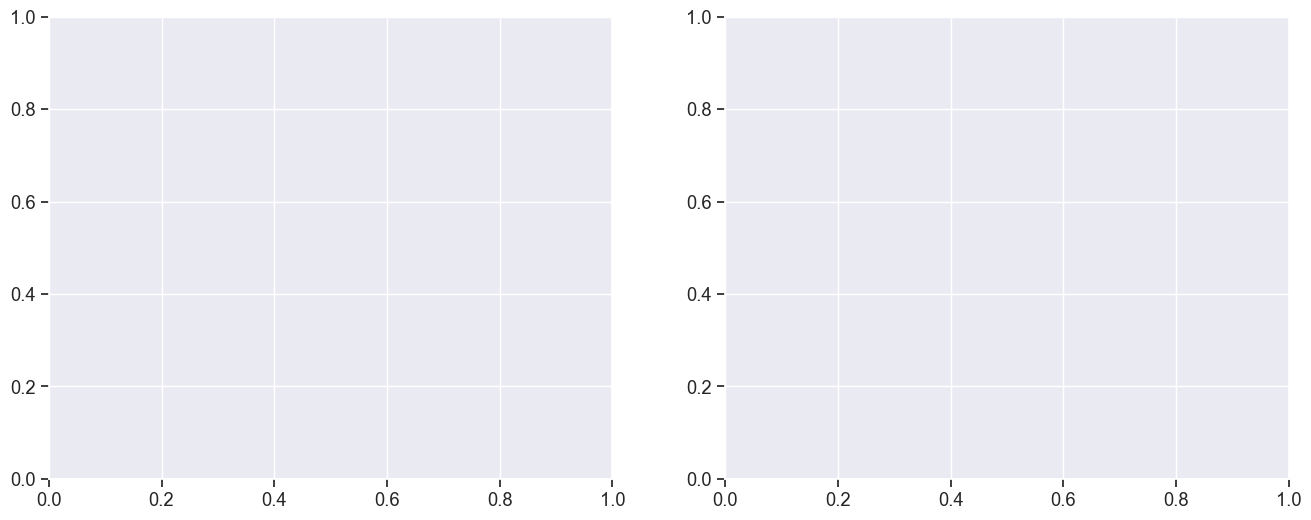

In [20]:
# Calculate Value at Risk (VaR) for crypto portfolio by regime
if returns_with_regime is not None:
    print("📊 Calculating VaR by regime...\n")
    
    # Define portfolio (equal weight)
    crypto_return_cols = [col for col in returns_with_regime.columns if '_return' in col]
    
    if crypto_return_cols:
        # Create equal-weighted portfolio
        returns_with_regime['portfolio_return'] = returns_with_regime[crypto_return_cols].mean(axis=1)
        
        # Calculate VaR for each regime
        confidence_levels = [0.95, 0.99]
        var_results = []
        
        for regime in returns_with_regime['regime'].unique():
            regime_returns = returns_with_regime[returns_with_regime['regime'] == regime]['portfolio_return']
            
            if len(regime_returns) > 30:
                for conf in confidence_levels:
                    # Historical VaR
                    var = np.percentile(regime_returns, (1-conf)*100)
                    
                    # Parametric VaR (assuming normal distribution)
                    mean = regime_returns.mean()
                    std = regime_returns.std()
                    var_parametric = mean + std * stats.norm.ppf(1-conf)
                    
                    var_results.append({
                        'Regime': regime,
                        'Confidence': f'{conf*100:.0f}%',
                        'VaR (Historical)': var,
                        'VaR (Parametric)': var_parametric,
                        'Mean Return': mean,
                        'Volatility': std,
                        'Sample Size': len(regime_returns)
                    })
        
        var_df = pd.DataFrame(var_results)
        
        print("✅ VaR calculated for all regimes")
        print("\n📋 Value at Risk (VaR) by Regime:")
        print("   (Negative values indicate potential losses)\n")
        display(var_df.style.format({
            'VaR (Historical)': '{:.4f}',
            'VaR (Parametric)': '{:.4f}',
            'Mean Return': '{:.4f}',
            'Volatility': '{:.4f}',
            'Sample Size': '{:.0f}'
        }).background_gradient(subset=['VaR (Historical)', 'VaR (Parametric)'], cmap='RdYlGn'))
        
        # Visualize VaR comparison
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Plot 1: VaR by regime (95% confidence)
        var_95 = var_df[var_df['Confidence'] == '95%']
        x = np.arange(len(var_95))
        width = 0.35
        
        axes[0].bar(x - width/2, var_95['VaR (Historical)'], width, label='Historical VaR', alpha=0.8)
        axes[0].bar(x + width/2, var_95['VaR (Parametric)'], width, label='Parametric VaR', alpha=0.8)
        axes[0].set_xlabel('Regime')
        axes[0].set_ylabel('VaR (Daily Return)')
        axes[0].set_title('Value at Risk (95% Confidence) by Regime', fontweight='bold')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(var_95['Regime'], rotation=45, ha='right')
        axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
        axes[0].legend()
        axes[0].grid(alpha=0.3, axis='y')
        
        # Plot 2: VaR by regime (99% confidence)
        var_99 = var_df[var_df['Confidence'] == '99%']
        x = np.arange(len(var_99))
        
        axes[1].bar(x - width/2, var_99['VaR (Historical)'], width, label='Historical VaR', alpha=0.8)
        axes[1].bar(x + width/2, var_99['VaR (Parametric)'], width, label='Parametric VaR', alpha=0.8)
        axes[1].set_xlabel('Regime')
        axes[1].set_ylabel('VaR (Daily Return)')
        axes[1].set_title('Value at Risk (99% Confidence) by Regime', fontweight='bold')
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(var_99['Regime'], rotation=45, ha='right')
        axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
        axes[1].legend()
        axes[1].grid(alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'var_by_regime.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Save VaR results to CSV
        var_df.to_csv(OUTPUT_DIR / 'var_by_regime.csv', index=False)
        print("\n✅ VaR analysis saved to outputs/")
    else:
        print("❌ No crypto return columns found for VaR calculation")
else:
    print("❌ Returns data with regime information not available")

## 8. Key Findings and Summary

In [21]:
# Generate summary of key findings
print("="*80)
print(" " * 20 + "BQ1 CORRELATION ANALYSIS - KEY FINDINGS")
print("="*80)

if unified_df is not None:
    print(f"\n📊 DATA COVERAGE")
    print(f"   • Date Range: {unified_df.index.min().strftime('%Y-%m-%d')} to {unified_df.index.max().strftime('%Y-%m-%d')}")
    print(f"   • Total Days: {len(unified_df):,}")
    print(f"   • Cryptocurrencies Analyzed: {len(crypto_data)}")
    print(f"   • Macro Indicators: {len(macro_data)}")

if regime_df is not None and 'regime' in regime_df.columns:
    print(f"\n🎯 REGIME IDENTIFICATION")
    regime_counts = regime_df['regime'].value_counts()
    for regime, count in regime_counts.items():
        pct = count / len(regime_df) * 100
        print(f"   • {regime:20s}: {count:5,} days ({pct:5.1f}%)")

if correlation_matrix is not None:
    print(f"\n📈 CORRELATION INSIGHTS")
    # Find strongest crypto-crypto correlations
    crypto_cols_clean = [col for col in correlation_matrix.columns if '_return' in col]
    if len(crypto_cols_clean) > 1:
        crypto_corr = correlation_matrix.loc[crypto_cols_clean, crypto_cols_clean]
        # Get upper triangle (excluding diagonal)
        mask = np.triu(np.ones_like(crypto_corr), k=1).astype(bool)
        crypto_corr_values = crypto_corr.where(mask)
        max_corr = crypto_corr_values.max().max()
        print(f"   • Highest Crypto-Crypto Correlation: {max_corr:.3f}")
    
    # Find strongest crypto-macro correlations
    crypto_cols_return = [col for col in correlation_matrix.columns if '_return' in col]
    macro_cols_change = [col for col in correlation_matrix.columns if '_change' in col]
    if crypto_cols_return and macro_cols_change:
        crypto_macro = correlation_matrix.loc[crypto_cols_return, macro_cols_change]
        max_cm_corr = crypto_macro.max().max()
        min_cm_corr = crypto_macro.min().min()
        print(f"   • Strongest Positive Crypto-Macro Correlation: {max_cm_corr:.3f}")
        print(f"   • Strongest Negative Crypto-Macro Correlation: {min_cm_corr:.3f}")

if var_df is not None:
    print(f"\n⚠️  PORTFOLIO RISK METRICS")
    print(f"   95% VaR Range (daily): {var_df[var_df['Confidence']=='95%']['VaR (Historical)'].min():.4f} to {var_df[var_df['Confidence']=='95%']['VaR (Historical)'].max():.4f}")
    print(f"   99% VaR Range (daily): {var_df[var_df['Confidence']=='99%']['VaR (Historical)'].min():.4f} to {var_df[var_df['Confidence']=='99%']['VaR (Historical)'].max():.4f}")
    
    # Identify highest risk regime
    highest_risk_regime = var_df[var_df['Confidence']=='99%'].nsmallest(1, 'VaR (Historical)')['Regime'].values[0]
    print(f"   Highest Risk Regime: {highest_risk_regime}")

print(f"\n📁 OUTPUT FILES GENERATED")
output_files = list(OUTPUT_DIR.glob('*.png')) + list(OUTPUT_DIR.glob('*.csv'))
for f in output_files:
    print(f"   • {f.name}")

print("\n" + "="*80)
print(" " * 25 + "ANALYSIS COMPLETE")
print("="*80)

                    BQ1 CORRELATION ANALYSIS - KEY FINDINGS

📊 DATA COVERAGE
   • Date Range: 2025-09-22 to 2025-10-22
   • Total Days: 36
   • Cryptocurrencies Analyzed: 5
   • Macro Indicators: 6

🎯 REGIME IDENTIFICATION
   • Risk-On             :    29 days ( 80.6%)
   • Tightening          :     7 days ( 19.4%)

📈 CORRELATION INSIGHTS
   • Highest Crypto-Crypto Correlation: 0.948
   • Strongest Positive Crypto-Macro Correlation: 0.228
   • Strongest Negative Crypto-Macro Correlation: -0.256

⚠️  PORTFOLIO RISK METRICS


KeyError: 'Confidence'

## Next Steps

Based on this correlation analysis (BQ1), the following steps are recommended:

1. **Regime Classification Model** (BQ1 continuation)
   - Develop machine learning classifier for regime prediction
   - Train model to predict regime switches 5-10 days in advance
   - Target: >80% classification accuracy

2. **Sentiment Analysis Integration** (BQ2)
   - Incorporate sentiment data to improve correlation predictions
   - Analyze how sentiment drives correlation breakdowns

3. **Tactical Allocation Signals** (BQ3)
   - Generate actionable trading signals based on regime transitions
   - Backtest strategies using historical regime data

4. **Dashboard Development**
   - Create real-time monitoring dashboard for regime tracking
   - Implement early warning system for correlation breakdown

5. **Risk Attribution Framework**
   - Decompose portfolio risk by regime and asset class
   - Develop attribution error metrics (<2% target)